<a href="https://colab.research.google.com/github/mohammedfaizan3103/DL/blob/main/DL_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Sem VI/DL/DL Lab/sign_language/sign_mnist_train.csv')

# Gradient Descent types

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adadelta, Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Load and preprocess Sign Language MNIST
df = pd.read_csv('/content/drive/MyDrive/Sem VI/DL/DL Lab/sign_language/sign_mnist_train.csv')
X_data = df.iloc[:, 1:].values / 255.0
y_data = to_categorical(df.iloc[:, 0].values, 26)

# Use a subset for faster comparison across 9 optimizers
X_train_opt, _, y_train_opt, _ = train_test_split(X_data, y_data, train_size=2000, stratify=df.iloc[:, 0].values, random_state=42)

def train_model(optimizer, batch_size, name):
    model = Sequential([
        Input(shape=(784,)),
        Dense(128, activation='relu'),
        Dense(26, activation='softmax')
    ])
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_opt, y_train_opt,
        epochs=20,
        batch_size=batch_size,
        verbose=0
    )

    final_loss = history.history['loss'][-1]
    final_acc = history.history['accuracy'][-1]

    print(f"{name:20s} | Loss: {final_loss:.4f} | Accuracy: {final_acc:.2f}")

(i) Batch Gradient Descent (BGD)

In [ ]:
train_model(
    optimizer=SGD(learning_rate=0.01),
    batch_size=len(X_train_opt),   # BGD uses entire subset
    name="Batch GD"
)

Batch GD             | Loss: 3.2026 | Accuracy: 0.05


(ii) Stochastic Gradient Descent (SGD)

In [ ]:
train_model(
    optimizer=SGD(learning_rate=0.01),
    batch_size=1,   # SGD uses 1 sample
    name="Stochastic GD"
)

Stochastic GD        | Loss: 0.9829 | Accuracy: 0.67


(iii) Mini-Batch Gradient Descent

In [ ]:
train_model(
    optimizer=SGD(learning_rate=0.01),
    batch_size=32,
    name="Mini-Batch GD"
)

Mini-Batch GD        | Loss: 1.9068 | Accuracy: 0.50


(iv) SGD with momentum

In [ ]:
train_model(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    batch_size=32,
    name="SGD + Momentum"
)

SGD + Momentum       | Loss: 0.8474 | Accuracy: 0.72


(v) SGD with nesterov momentum

In [ ]:
train_model(
    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    batch_size=32,
    name="SGD + Nesterov"
)

SGD + Nesterov       | Loss: 0.6261 | Accuracy: 0.81


(vi) Adagrad

In [ ]:
train_model(
    optimizer=Adagrad(learning_rate=0.01),
    batch_size=32,
    name="Adagrad"
)

Adagrad              | Loss: 1.4446 | Accuracy: 0.62


(vii) RMSProp

In [ ]:
train_model(
    optimizer=RMSprop(learning_rate=0.001),
    batch_size=32,
    name="RMSProp"
)

RMSProp              | Loss: 1.4170 | Accuracy: 0.59


(viii) AdaDelta

In [ ]:
train_model(
    optimizer=Adadelta(learning_rate=1.0),
    batch_size=32,
    name="Adadelta"
)

Adadelta             | Loss: 1.1829 | Accuracy: 0.65


(ix) Adam

In [ ]:
train_model(
    optimizer=Adam(learning_rate=0.001),
    batch_size=32,
    name="Adam"
)

Adam                 | Loss: 1.1565 | Accuracy: 0.67


SGD with nesterov momentun produced the best results for the sign language dataset.

# Regularization

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Sem VI/DL/DL Lab/sign_language/sign_mnist_train.csv')

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# First column is the label
X = df.iloc[:, 1:].values    # pixel values
y = df.iloc[:, 0].values    # class labels

# Normalize
X = X / 255.0

# Flatten
X = X.reshape(X.shape[0], 28*28)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

num_classes = len(set(y))
y_train = to_categorical(y_train, 26)
y_test = to_categorical(y_test, 26)

print(X_train.shape)
print(y_train.shape)

(21964, 784)
(21964, 26)


(i) L2 Regularization

In [ ]:
from tensorflow.keras import layers, models, regularizers

model_l2 = model = models.Sequential([
        layers.Dense(128, activation='relu',
                     input_shape=(784,),
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(26, activation='softmax')
    ])

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model_l2.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

test_loss, test_acc = model_l2.evaluate(X_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

train_loss, train_acc = model_l2.evaluate(X_train, y_train)

print(f"Train accuracy: {train_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.3287 - loss: 2.3847 - val_accuracy: 0.4880 - val_loss: 1.6827
Epoch 2/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5980 - loss: 1.4134 - val_accuracy: 0.6893 - val_loss: 1.1887
Epoch 3/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7039 - loss: 1.0878 - val_accuracy: 0.6790 - val_loss: 1.1569
Epoch 4/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7759 - loss: 0.8874 - val_accuracy: 0.7487 - val_loss: 0.9603
Epoch 5/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8292 - loss: 0.7430 - val_accuracy: 0.8136 - val_loss: 0.7746
Epoch 6/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8683 - loss: 0.6379 - val_accuracy: 0.8038 - val_loss: 0.7484
Epoch 7/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8863 - loss: 0.5817 - val_accuracy: 0.9003 - val_loss: 0.5579
Epoch 8/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9147 - loss: 0.5083 - val_accuracy: 0.

(ii) data augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# data is already flattened, image generator needs image data
X_train_img = X_train.reshape(-1, 28, 28, 1)

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False,
    vertical_flip=False
)

# compute statistics required for data augmentation
datagen.fit(X_train_img)

# generate augmented images
X_train_img = next(
    datagen.flow(
        X_train_img,
        batch_size=X_train_img.shape[0],
        shuffle=False
    )
)

# flatten again
X_train_aug = X_train_img.reshape(X_train_img.shape[0], 28*28)

print(X_train_aug.shape)

(21964, 784)


In [ ]:
model_l2 = model = models.Sequential([
        layers.Dense(128, activation='relu',
                     input_shape=(784,),
                     ),
        layers.Dense(128, activation='relu',
                     ),
        layers.Dense(26, activation='softmax')
    ])

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model_l2.fit(
    X_train_aug,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

test_loss, test_acc = model_l2.evaluate(X_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

train_loss, train_acc = model_l2.evaluate(X_train_aug, y_train)

print(f"Train accuracy: {train_acc:.4f}")

Epoch 1/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.2103 - loss: 2.6154 - val_accuracy: 0.2784 - val_loss: 2.2751
Epoch 2/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3540 - loss: 2.0333 - val_accuracy: 0.3549 - val_loss: 2.0620
Epoch 3/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4364 - loss: 1.7485 - val_accuracy: 0.4364 - val_loss: 1.7195
Epoch 4/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4992 - loss: 1.5453 - val_accuracy: 0.4949 - val_loss: 1.5349
Epoch 5/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5394 - loss: 1.3972 - val_accuracy: 0.5520 - val_loss: 1.3963
Epoch 6/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5854 - loss: 1.2659 - val_accuracy: 0.5315 - val_loss: 1.4346
Epoch 7/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6135 - loss: 1.1779 - val_accuracy: 0.5964 - val_loss: 1.2235
Epoch 8/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6414 - loss: 1.0882 - val_accuracy: 0.

Data Augmentation shows increase in Test accuracy but a drop in train accuracy because it contains augmented data. It reduced overfitting by reducing test accuracy

(iii) Early Stopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

earlystop = EarlyStopping(
    monitor='val_accuracy',
    patience=2,
    restore_best_weights=True
)

model = models.Sequential([
        layers.Dense(128, activation='relu',
                     input_shape=(784,),),
        layers.Dense(128, activation='relu',),
        layers.Dense(26, activation='softmax')
    ])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[earlystop]
)

test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

train_loss, train_acc = model.evaluate(X_train, y_train)

print(f"Train accuracy: {train_acc:.4f}")

Epoch 1/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3411 - loss: 2.1604 - val_accuracy: 0.4821 - val_loss: 1.5648
Epoch 2/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6185 - loss: 1.1967 - val_accuracy: 0.6210 - val_loss: 1.1538
Epoch 3/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7278 - loss: 0.8608 - val_accuracy: 0.7018 - val_loss: 0.8715
Epoch 4/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8032 - loss: 0.6239 - val_accuracy: 0.8466 - val_loss: 0.5326
Epoch 5/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8576 - loss: 0.4567 - val_accuracy: 0.7844 - val_loss: 0.6028
Epoch 6/10
550/550 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8860 - loss: 0.3590 - val_accuracy: 0.7564 - val_loss: 0.6949
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8417 - loss: 0.5312
Test accuracy: 0.8417
687/687 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8535 - loss: 0.5023
Train accuracy: 0.8535


Early Stopping stopped after 6 epochs, improved accuracy with a very small gap between training and testing (no overfitting)

(iv) Drop Out

In [ ]:
model = models.Sequential([
        layers.Dense(256, activation='relu', input_shape=(784,)),
        layers.Dropout(0.2),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(26, activation='softmax')
    ])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
)

test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

train_loss, train_acc = model.evaluate(X_train, y_train)

print(f"Train accuracy: {train_acc:.4f}")

Epoch 1/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.2708 - loss: 2.2863
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4953 - loss: 1.4738
Epoch 3/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5952 - loss: 1.1696
Epoch 4/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6606 - loss: 0.9687
Epoch 5/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6985 - loss: 0.8589
Epoch 6/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7355 - loss: 0.7546
Epoch 7/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7580 - loss: 0.6938
Epoch 8/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7865 - loss: 0.6096
Epoch 9/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8024 - loss: 0.5649
Epoch 10/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8093 - loss: 0.5474
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9583 - loss: 0.1871
Test accuracy: 0.9583
687/687 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step -

In [ ]:
model = models.Sequential([
        layers.Dense(256, activation='relu', input_shape=(784,)),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(26, activation='softmax')
    ])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
)

test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

train_loss, train_acc = model.evaluate(X_train, y_train)

print(f"Train accuracy: {train_acc:.4f}")

Epoch 1/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2095 - loss: 2.5158
Epoch 2/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3771 - loss: 1.8317
Epoch 3/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4591 - loss: 1.5808
Epoch 4/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5001 - loss: 1.4378
Epoch 5/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5357 - loss: 1.3323
Epoch 6/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5665 - loss: 1.2450
Epoch 7/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5831 - loss: 1.1982
Epoch 8/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6075 - loss: 1.1314
Epoch 9/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6155 - loss: 1.1059
Epoch 10/10
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6287 - loss: 1.0675
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7869 - loss: 0.7071
Test accuracy: 0.7869
687/687 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step -

Dropout with 0.2 showed very high accuracy where as dropout with 0.3 showed very low indicating 0.3 is too much and the model is underfitting

(v) Parameter sharing and tying

In [ ]:
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model

# Shared Layer
shared_dense = Dense(64, activation='relu')

# Two inputs
input1 = Input(shape=(784,))
input2 = Input(shape=(784,))

# Apply SAME layer (parameter sharing)
encoded1 = shared_dense(input1)
encoded2 = shared_dense(input2)

# Merge
merged = Concatenate()([encoded1, encoded2])
output = Dense(26, activation='softmax')(merged)

model = Model(inputs=[input1, input2], outputs=output)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train (using same data twice just for demo)
model.fit([X_train, X_train], y_train,
          epochs=10,
          batch_size=256,
          validation_split=0.2)

test_loss, test_acc = model.evaluate([X_test, X_test], y_test)
print("Test accuracy (Parameter Sharing):", test_acc)

train_loss, train_acc = model.evaluate([X_train, X_train], y_train)

print(f"Train accuracy: {train_acc:.4f}")

Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.1439 - loss: 3.0092 - val_accuracy: 0.2511 - val_loss: 2.7651
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3255 - loss: 2.4950 - val_accuracy: 0.3535 - val_loss: 2.3046
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4216 - loss: 2.0835 - val_accuracy: 0.4721 - val_loss: 1.9336
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4992 - loss: 1.7951 - val_accuracy: 0.5072 - val_loss: 1.7085
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5403 - loss: 1.5963 - val_accuracy: 0.5461 - val_loss: 1.5381
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5785 - loss: 1.4465 - val_accuracy: 0.5912 - val_loss: 1.4151
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6222 - loss: 1.3248 - val_accuracy: 0.6305 - val_loss: 1.3150
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6478 - loss: 1.2283 - val_accuracy: 0.6551 - val_loss

Parameter sharing did not give very good accuracy results for this particular dataset

(vi) Ensemble Methods

In [ ]:
from tensorflow.keras import layers, models

# Model 1: Simple Dense
model1 = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(784,)),
    layers.Dense(26, activation='softmax')
])

model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model1.fit(X_train, y_train,
           epochs=10, batch_size=256, verbose=0)

# Model 2: Medium Dense
model2 = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(26, activation='softmax')
])

model2.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model2.fit(X_train, y_train,
           epochs=10, batch_size=256, verbose=0)

# Model 3: Deeper Dense
model3 = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(26, activation='softmax')
])

model3.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model3.fit(X_train, y_train,
           epochs=10, batch_size=256, verbose=0)

# Individual Model Accuracies
print("Model 1 Accuracy:", model1.evaluate(X_test, y_test, verbose=0)[1])
print("Model 2 Accuracy:", model2.evaluate(X_test, y_test, verbose=0)[1])
print("Model 3 Accuracy:", model3.evaluate(X_test, y_test, verbose=0)[1])

# Ensemble (Soft Voting)

pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)

# Average predictions
ensemble_pred = (pred1 + pred2 + pred3) / 3

# Convert probabilities to class labels
ensemble_classes = np.argmax(ensemble_pred, axis=1)

# Convert y_test from one-hot encoding to class labels
y_test_labels = np.argmax(y_test, axis=1)

# Compute ensemble accuracy
ensemble_accuracy = np.mean(ensemble_classes == y_test_labels)

print("Ensemble Accuracy:", ensemble_accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 1 Accuracy: 0.740302324295044
Model 2 Accuracy: 0.7943907976150513
Model 3 Accuracy: 0.8184301853179932
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Ensemble Accuracy: 0.8138772536878528


(vii) Adding noise to the inputs and outputs


In [ ]:
# Add Noise to INPUTS
noise_factor = 0.2
x_train_noisy = X_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=X_train.shape)

# Keep pixel values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.)

# Add Noise to OUTPUTS (Label Noise)
# Randomly flip 10% of labels
noise_ratio = 0.1
num_samples = int(noise_ratio * y_train.shape[0])

random_indices = np.random.choice(y_train.shape[0], num_samples, replace=False)

for idx in random_indices:
    random_label = np.random.randint(0, 26)
    y_train[idx] = to_categorical(random_label, 26)

# Build Model (same as original)
model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(26, activation='softmax')
    ])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train_noisy,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.2
)

# Evaluate on clean test data
test_loss, test_acc = model.evaluate(X_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.1298 - loss: 3.0142 - val_accuracy: 0.2135 - val_loss: 2.7452
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3093 - loss: 2.4310 - val_accuracy: 0.3592 - val_loss: 2.2778
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4131 - loss: 2.1110 - val_accuracy: 0.4234 - val_loss: 2.0810
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4682 - loss: 1.9433 - val_accuracy: 0.4721 - val_loss: 1.9689
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5118 - loss: 1.8248 - val_accuracy: 0.4919 - val_loss: 1.8959
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5381 - loss: 1.7352 - val_accuracy: 0.5065 - val_loss: 1.8761
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5667 - loss: 1.6580 - val_accuracy: 0.5308 - val_loss: 1.7832
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5923 - loss: 1.5991 - val_accuracy: 0.5479 - val_loss

Dropout with 0.2 showed the highest test and train accuracy of all.

Early Stopping also shows very good performance, while stops the model for training too much -> also improves efficiency by not training for a long time

# CNN

Implement CNN on MNITST Dataset

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Sem VI/DL/DL Lab/sign_language/sign_mnist_train.csv')
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

# Normalize pixel values to [0, 1]
X = X / 255.0

# Reshape for CNN: (samples, height, width, channels)
X = X.reshape(-1, 28, 28, 1).astype('float32')

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# One-hot encoding for 26 classes
n_classes = 26
Y_train = to_categorical(y_train, n_classes)
Y_test = to_categorical(y_test, n_classes)

# Build the CNN model
model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPool2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(n_classes, activation='softmax')
])

model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

# Train the model
model.fit(X_train, Y_train, batch_size=128, epochs=10, validation_data=(X_test, Y_test))

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, Y_test)
print(f"Test accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.2725 - loss: 2.4151 - val_accuracy: 0.7350 - val_loss: 1.1020
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6439 - loss: 1.0918 - val_accuracy: 0.8904 - val_loss: 0.4494
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7750 - loss: 0.6709 - val_accuracy: 0.9512 - val_loss: 0.2269
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8437 - loss: 0.4580 - val_accuracy: 0.9803 - val_loss: 0.1255
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8806 - loss: 0.3546 - val_accuracy: 0.9852 - val_loss: 0.0879
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9080 - loss: 0.2712 - val_accuracy: 0.9962 - val_loss: 0.0462
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9273 - loss: 0.2192 - val_accuracy: 0.9982 - val_loss: 0.0251
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9349 - loss: 0.1896 - val_accuracy: 0

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

df = pd.read_csv('/content/drive/MyDrive/Sem VI/DL/DL Lab/sign_language/sign_mnist_train.csv')
X = df.iloc[:, 1:].values    # pixel values
y = df.iloc[:, 0].values    # class labels

# Normalize
X = X / 255.0

# reshape for CNN
X = X.reshape(-1, 28, 28, 1).astype('float32')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. One-hot encode labels
n_classes = 26
print("Shape before one-hot encoding:", y_train.shape)
Y_train = to_categorical(y_train, n_classes)
Y_test  = to_categorical(y_test,  n_classes)
print("Shape after one-hot encoding: ", Y_train.shape)

# 6. Build the CNN
model = Sequential()

# Convolutional Layer -1
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu',
                 padding='same', input_shape=(28, 28, 1)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Convolutional Layer - 2
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Fully connected layer
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(n_classes, activation='softmax'))

model.summary()

Shape before one-hot encoding: (21964,)
Shape after one-hot encoding:  (21964, 26)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,706 (1.62 MB)

 Trainable params: 423,706 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='categorical_crossentropy',
               metrics=['accuracy'],
               optimizer='adam')

model.fit(X_train, Y_train,
          batch_size=128,
          epochs=10,
          validation_data=(X_test, Y_test))

#  8. Evaluate
test_loss, test_acc = model.evaluate(X_test, Y_test)
print("Test loss:    ", test_loss)
print("Test accuracy:", test_acc)

Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - accuracy: 0.2677 - loss: 2.4415 - val_accuracy: 0.7663 - val_loss: 0.9998
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.6491 - loss: 1.0612 - val_accuracy: 0.9204 - val_loss: 0.3985
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7732 - loss: 0.6633 - val_accuracy: 0.9625 - val_loss: 0.2054
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8319 - loss: 0.4822 - val_accuracy: 0.9760 - val_loss: 0.1396
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8695 - loss: 0.3842 - val_accuracy: 0.9947 - val_loss: 0.0584
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8952 - loss: 0.3052 - val_accuracy: 0.9976 - val_loss: 0.0360
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9143 - loss: 0.2489 - val_accuracy: 0.9993 - val_loss: 0.0247
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9224 - loss: 0.2233 - val_accuracy:

# Pretrained models

LeNet

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Activation
from keras.models import Sequential
from sklearn.model_selection import train_test_split

df = pd.read_csv('/content/drive/MyDrive/Sem VI/DL/DL Lab/sign_language/sign_mnist_train.csv')
# First column is the label
X = df.iloc[:, 1:].values    # pixel values
y = df.iloc[:, 0].values    # class labels

# Normalize
X = X / 255.0

# Reshape for CNN
X = X.reshape(-1, 28, 28, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Validation split from training data
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)


num_classes = len(set(y))
y_train = to_categorical(y_train, 26)
y_test = to_categorical(y_test, 26)
y_val = to_categorical(y_val, 26)

LeNet5 = Sequential()

LeNet5.add(Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(28, 28, 1)))
LeNet5.add(AveragePooling2D((2, 2)))
LeNet5.add(Conv2D(16, kernel_size=(5, 5), activation='tanh'))
LeNet5.add(AveragePooling2D((2, 2)))
LeNet5.add(Flatten())
LeNet5.add(Dense(120, activation='tanh'))
LeNet5.add(Dense(84, activation='tanh'))
LeNet5.add(Dense(26, activation='softmax'))

LeNet5.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

LeNet5.fit(X_train, y_train, epochs=20, batch_size=128, validation_data=(X_val, y_val))

test_loss, test_acc = LeNet5.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.3878 - loss: 2.1421 - val_accuracy: 0.6022 - val_loss: 1.3070
Epoch 2/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7245 - loss: 0.9706 - val_accuracy: 0.7897 - val_loss: 0.7496
Epoch 3/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8591 - loss: 0.5667 - val_accuracy: 0.9030 - val_loss: 0.4382
Epoch 4/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9372 - loss: 0.3275 - val_accuracy: 0.9704 - val_loss: 0.2510
Epoch 5/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9803 - loss: 0.1824 - val_accuracy: 0.9900 - val_loss: 0.1468
Epoch 6/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9943 - loss: 0.1060 - val_accuracy: 0.9968 - val_loss: 0.0860
Epoch 7/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9985 - loss: 0.0638 - val_accuracy: 0.9982 - val_loss: 0.0567
Epoch 8/20
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9992 - loss: 0.0417 - val_accuracy: 0


Observations:
LeNet architecture produced very high accuracy value for the sign language dataset

AlexNet

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from keras.models import Sequential
from sklearn.model_selection import train_test_split
from keras.optimizers import Adam
import tensorflow as tf

df = pd.read_csv('/content/drive/MyDrive/Sem VI/DL/DL Lab/sign_language/sign_mnist_train.csv')
# First column is the label
X = df.iloc[:, 1:].values    # pixel values
y = df.iloc[:, 0].values    # class labels

# Normalize
X = X / 255.0

# Reshape for CNN
X = X.reshape(-1, 28, 28, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Validation split from training data
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)


num_classes = 26 # Corrected: Explicitly set to 26 for sign language alphabet
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)
y_val = to_categorical(y_val, num_classes)

# Resize images for AlexNet input (112x112)
X_train_resized = tf.image.resize(X_train, (112, 112)).numpy()
X_val_resized = tf.image.resize(X_val, (112, 112)).numpy()
X_test_resized = tf.image.resize(X_test, (112, 112)).numpy()


AlexNet = Sequential()
# Layer 1: Convolution + MaxPooling
AlexNet.add(Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(112, 112, 1)))
AlexNet.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Layer 2: Convolution + MaxPooling
AlexNet.add(Conv2D(256, (5, 5), padding='same', activation='relu'))
AlexNet.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Layer 3-5: Convolution Layers
AlexNet.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
AlexNet.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
AlexNet.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
AlexNet.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Flatten + Fully Connected Layers
AlexNet.add(Flatten())
AlexNet.add(Dense(4096, activation='relu'))
AlexNet.add(Dropout(0.5))
AlexNet.add(Dense(4096, activation='relu'))
AlexNet.add(Dropout(0.5))

# Output Layer
AlexNet.add(Dense(num_classes, activation='softmax')) # Changed to num_classes

AlexNet.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

AlexNet.fit(X_train_resized, y_train, epochs=5, batch_size=128, validation_data=(X_val_resized, y_val))


test_loss, test_acc = AlexNet.evaluate(X_test_resized, y_test)
print('Test accuracy:', test_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 27s 103ms/step - accuracy: 0.0447 - loss: 3.1925 - val_accuracy: 0.0464 - val_loss: 3.1808
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.0410 - loss: 3.1824 - val_accuracy: 0.0464 - val_loss: 3.1780
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.0439 - loss: 3.1801 - val_accuracy: 0.0423 - val_loss: 3.1787
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.0447 - loss: 3.1797 - val_accuracy: 0.0437 - val_loss: 3.1773
Epoch 5/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.0428 - loss: 3.1786 - val_accuracy: 0.0473 - val_loss: 3.1768
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0472 - loss: 3.1768
Test accuracy: 0.04716809466481209


Observations:
AlexNet produced very low accuracy for sign language dataset. Reason maybe that AlexNet is optimized for very high resolution images and not for simpler datasets like sign language, even though the dataset was upscaled it introduces blur in the image and applying the convulutional filters to these may lead to loss of significant data

ZFNet

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from keras.models import Sequential
from sklearn.model_selection import train_test_split
from keras.optimizers import Adam
import tensorflow as tf

df = pd.read_csv('/content/drive/MyDrive/Sem VI/DL/DL Lab/sign_language/sign_mnist_train.csv')
# First column is the label
X = df.iloc[:, 1:].values    # pixel values
y = df.iloc[:, 0].values    # class labels

# Normalize
X = X / 255.0

# Reshape for CNN
X = X.reshape(-1, 28, 28, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Validation split from training data
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)


num_classes = 26 # Corrected: Explicitly set to 26 for sign language alphabet
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)
y_val = to_categorical(y_val, num_classes)

# Resize images for AlexNet input (112x112)
X_train_resized = tf.image.resize(X_train, (112, 112)).numpy()
X_val_resized = tf.image.resize(X_val, (112, 112)).numpy()
X_test_resized = tf.image.resize(X_test, (112, 112)).numpy()

ZFNet = Sequential()
# Layer 1: Convolution + MaxPooling
ZFNet.add(Conv2D(96, (7, 7), strides=(2, 2), activation='relu', input_shape=(112, 112, 1)))
ZFNet.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Layer 2: Convolution + MaxPooling
ZFNet.add(Conv2D(256, (5, 5), strides=(2, 2), padding='same', activation='relu'))
ZFNet.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Layer 3-5: Convolution Layers
ZFNet.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
ZFNet.add(Conv2D(384, (3, 3), padding='same', activation='relu'))
ZFNet.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
ZFNet.add(MaxPooling2D((3, 3), strides=(2, 2)))

# Flatten + Fully Connected Layers
ZFNet.add(Flatten())
ZFNet.add(Dense(4096, activation='relu'))
ZFNet.add(Dropout(0.5))
ZFNet.add(Dense(4096, activation='relu'))
ZFNet.add(Dropout(0.5))

# Output Layer
ZFNet.add(Dense(26, activation='softmax'))

ZFNet.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

ZFNet.fit(X_train_resized, y_train, epochs=5, batch_size=128, validation_data=(X_val_resized, y_val))


test_loss, test_acc = ZFNet.evaluate(X_test_resized, y_test)
print('Test accuracy:', test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 33s 133ms/step - accuracy: 0.0455 - loss: 3.1918 - val_accuracy: 0.0451 - val_loss: 3.1815
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.0455 - loss: 3.1816 - val_accuracy: 0.0473 - val_loss: 3.1800
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.0420 - loss: 3.1802 - val_accuracy: 0.0473 - val_loss: 3.1782
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.0460 - loss: 3.1794 - val_accuracy: 0.0451 - val_loss: 3.1774
Epoch 5/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.0450 - loss: 3.1788 - val_accuracy: 0.0437 - val_loss: 3.1773
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0439 - loss: 3.1773
Test accuracy: 0.043890003114938736


Observations: similar to Alexnet did not produce good results for sign language dataset because such complex models are not suited for simpler low resolution images

VGGNet

In [ ]:
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from keras.models import Sequential
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras.optimizers import Adam
import tensorflow as tf
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Sem VI/DL/DL Lab/sign_language/sign_mnist_train.csv')
X = df.iloc[:, 1:].values    # pixel values
y = df.iloc[:, 0].values    # class labels

X = X / 255.0
X = X.reshape(-1, 28, 28, 1)

# Then resize
x_train_full = tf.image.resize(X, (112, 112)).numpy()
y_train_full = y

# Split data into training and test sets
x_train, x_test, y_train, y_test = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

num_classes = 26 # For sign language
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

# validation split
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

VGGNet = Sequential()

# Block 1
VGGNet.add(Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(112,112,1)))
VGGNet.add(Conv2D(64, (3,3), activation='relu', padding='same'))
VGGNet.add(MaxPooling2D((2,2)))

# Block 2
VGGNet.add(Conv2D(128, (3,3), activation='relu', padding='same'))
VGGNet.add(Conv2D(128, (3,3), activation='relu', padding='same'))
VGGNet.add(MaxPooling2D((2,2)))

# Block 3
VGGNet.add(Conv2D(256, (3,3), activation='relu', padding='same'))
VGGNet.add(Conv2D(256, (3,3), activation='relu', padding='same'))
VGGNet.add(Conv2D(256, (3,3), activation='relu', padding='same'))
VGGNet.add(MaxPooling2D((2,2)))

# Block 4
VGGNet.add(Conv2D(512, (3,3), activation='relu', padding='same'))
VGGNet.add(Conv2D(512, (3,3), activation='relu', padding='same'))
VGGNet.add(Conv2D(512, (3,3), activation='relu', padding='same'))
VGGNet.add(MaxPooling2D((2,2)))

# Block 5
VGGNet.add(Conv2D(512, (3,3), activation='relu', padding='same'))
VGGNet.add(Conv2D(512, (3,3), activation='relu', padding='same'))
VGGNet.add(Conv2D(512, (3,3), activation='relu', padding='same'))
VGGNet.add(MaxPooling2D((2,2)))

# FC Layers
VGGNet.add(Flatten())
VGGNet.add(Dense(4096, activation='relu'))
VGGNet.add(Dropout(0.5))
VGGNet.add(Dense(4096, activation='relu'))
VGGNet.add(Dropout(0.5))

# Output
VGGNet.add(Dense(num_classes, activation='softmax')) # Changed to num_classes

VGGNet.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Model summary
VGGNet.summary()

VGGNet.fit(x_train, y_train, epochs=5, batch_size=128, validation_data=(x_val, y_val))


test_loss, test_acc = VGGNet.evaluate(x_test, y_test)
print('Test accuracy:', test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 112, 112, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    18,878,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │       106,522 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,479,834 (192.57 MB)

 Trainable params: 50,479,834 (192.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 181s 880ms/step - accuracy: 0.0443 - loss: 3.1908 - val_accuracy: 0.0396 - val_loss: 3.1825
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 78s 504ms/step - accuracy: 0.0420 - loss: 3.1822 - val_accuracy: 0.0451 - val_loss: 3.1792
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 78s 504ms/step - accuracy: 0.0452 - loss: 3.1804 - val_accuracy: 0.0473 - val_loss: 3.1787
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 78s 504ms/step - accuracy: 0.0425 - loss: 3.1793 - val_accuracy: 0.0473 - val_loss: 3.1774
Epoch 5/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 78s 503ms/step - accuracy: 0.0454 - loss: 3.1789 - val_accuracy: 0.0464 - val_loss: 3.1777
172/172 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - accuracy: 0.0466 - loss: 3.1776
Test accuracy: 0.046621743589639664


Observations: VGGNet is an extremeley complex dataset that takes lot of execution time and RAM to run (even for simpler images). It is not suited for simpler images and gives poor accuracy for mnist dataset

GoogleNet

In [ ]:
from keras.layers import Conv2D, AveragePooling2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, Input
from keras.datasets import mnist
from keras.models import Sequential
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras.optimizers import Adam
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = mnist.load_data()


x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

# Then resize
x_train = tf.image.resize(x_train, (112, 112))
x_test = tf.image.resize(x_test, (112, 112))


x_train = x_train.numpy()
x_test = x_test.numpy()

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# validation
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42
)

input = Input(shape=(112,112,1))



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
import tensorflow as tf
from keras.layers import Conv2D, MaxPooling2D, AveragePooling2D
from keras.layers import Input, Dense, Dropout, Flatten, concatenate
from keras.models import Model
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Sem VI/DL/DL Lab/sign_language/sign_mnist_train.csv')
X = df.iloc[:, 1:].values    # pixel values
y = df.iloc[:, 0].values    # class labels

X = X / 255.0
X = X.reshape(-1, 28, 28, 1)

# Then resize
x_train_full = tf.image.resize(X, (112, 112)).numpy()
y_train_full = y

num_classes = 26 # For sign language

x_train, x_test, y_train, y_test = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)


# INCEPTION BLOCK
def inception_module(x, f1, f3r, f3, f5r, f5, pool_proj):
    # 1x1
    conv1 = Conv2D(f1, (1,1), padding='same', activation='relu')(x)

    # 1x1 -> 3x3
    conv3 = Conv2D(f3r, (1,1), padding='same', activation='relu')(x)
    conv3 = Conv2D(f3, (3,3), padding='same', activation='relu')(conv3)

    # 1x1 -> 5x5
    conv5 = Conv2D(f5r, (1,1), padding='same', activation='relu')(x)
    conv5 = Conv2D(f5, (5,5), padding='same', activation='relu')(conv5)

    # pooling -> 1x1
    pool = MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    pool = Conv2D(pool_proj, (1,1), padding='same', activation='relu')(pool)

    # concatenate all
    output = concatenate([conv1, conv3, conv5, pool], axis=-1)
    return output

input_layer = Input(shape=(112,112,1))

x = Conv2D(64, (7,7), strides=2, padding='same', activation='relu')(input_layer)
x = MaxPooling2D((3,3), strides=2, padding='same')(x)

x = Conv2D(192, (3,3), padding='same', activation='relu')(x)
x = MaxPooling2D((3,3), strides=2, padding='same')(x)

# Inception blocks
x = inception_module(x, 64, 96, 128, 16, 32, 32)   # 3a
x = inception_module(x, 128, 128, 192, 32, 96, 64) # 3b
x = MaxPooling2D((3,3), strides=2, padding='same')(x)

x = inception_module(x, 192, 96, 208, 16, 48, 64)  # 4a
x = inception_module(x, 160, 112, 224, 24, 64, 64) # 4b
x = inception_module(x, 128, 128, 256, 24, 64, 64) # 4c
x = inception_module(x, 112, 144, 288, 32, 64, 64) # 4d
x = inception_module(x, 256, 160, 320, 32, 128,128)# 4e
x = MaxPooling2D((3,3), strides=2, padding='same')(x)

x = inception_module(x, 256, 160, 320, 32, 128,128)# 5a
x = inception_module(x, 384, 192, 384, 48, 128,128)# 5b

x = AveragePooling2D((4,4))(x)
x = Flatten()(x)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation='softmax')(x) # Changed to num_classes

model = Model(inputs=input_layer, outputs=output)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

model.fit(x_train, y_train, epochs=5, batch_size=128,
          validation_data=(x_val, y_val))

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 112, 112,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 56, 56,    │      3,200 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 28, 28,    │          0 │ conv2d_13[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 28, 28,    │    110,784 │ max_pooling2d_5[… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 14, 14,    │          0 │ conv2d_14[0][0]   │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 14, 14,    │     18,528 │ max_pooling2d_6[… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 14, 14,    │      3,088 │ max_pooling2d_6[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 14, 14,    │          0 │ max_pooling2d_6[… │
│ (MaxPooling2D)      │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 14, 14,    │     12,352 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 14, 14,    │    110,720 │ conv2d_16[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 14, 14,    │     12,832 │ conv2d_18[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 14, 14,    │      6,176 │ max_pooling2d_7[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 14, 14,    │          0 │ conv2d_15[0][0],  │
│ (Concatenate)       │ 256)              │            │ conv2d_17[0][0],  │
│                     │                   │            │ conv2d_19[0][0],  │
│                     │                   │            │ conv2d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 14, 14,    │     32,896 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 14, 14,    │      8,224 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 14, 14,    │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 256)              │            │                 

 Total params: 5,989,770 (22.85 MB)

 Trainable params: 5,989,770 (22.85 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 98s 367ms/step - accuracy: 0.0463 - loss: 3.1936 - val_accuracy: 0.0432 - val_loss: 3.1834
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 20s 128ms/step - accuracy: 0.0430 - loss: 3.1826 - val_accuracy: 0.0473 - val_loss: 3.1792
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - accuracy: 0.0454 - loss: 3.1836 - val_accuracy: 0.0451 - val_loss: 3.1784
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 20s 126ms/step - accuracy: 0.0461 - loss: 3.1798 - val_accuracy: 0.0446 - val_loss: 3.1775
Epoch 5/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 21s 134ms/step - accuracy: 0.0442 - loss: 3.1795 - val_accuracy: 0.0473 - val_loss: 3.1773
172/172 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.0472 - loss: 3.1773
Test accuracy: 0.04716809466481209


Google Net also suffers from the same problem as VGGNet and gives a very low accuracy score

ResNet

In [ ]:
import tensorflow as tf
from keras.layers import Conv2D, BatchNormalization, Activation
from keras.layers import Add, Input, MaxPooling2D
from keras.layers import GlobalAveragePooling2D, Dense
from keras.models import Model
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import pandas as pd

# DATA
df = pd.read_csv('/content/drive/MyDrive/Sem VI/DL/DL Lab/sign_language/sign_mnist_train.csv')
X = df.iloc[:, 1:].values    # pixel values
y = df.iloc[:, 0].values    # class labels

X = X / 255.0
X = X.reshape(-1, 28, 28, 1)

x_train_full = tf.image.resize(X, (112, 112)).numpy()
y_train_full = y

num_classes = 26 # For sign language

x_train, x_test, y_train, y_test = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

# RESIDUAL BLOCK
def residual_block(x, filters, stride=1):
    shortcut = x

    # First conv
    x = Conv2D(filters, (3,3), strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # Second conv
    x = Conv2D(filters, (3,3), padding='same')(x)
    x = BatchNormalization()(x)

    # Match dimensions if needed
    if stride != 1:
        shortcut = Conv2D(filters, (1,1), strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # Add skip connection
    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x

input_layer = Input(shape=(112,112,1))

x = Conv2D(64, (7,7), strides=2, padding='same')(input_layer)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = MaxPooling2D((3,3), strides=2, padding='same')(x)

# Residual blocks
x = residual_block(x, 64)
x = residual_block(x, 64)

x = residual_block(x, 128, stride=2)
x = residual_block(x, 128)

x = residual_block(x, 256, stride=2)
x = residual_block(x, 256)

x = residual_block(x, 512, stride=2)
x = residual_block(x, 512)

# Final layers
x = GlobalAveragePooling2D()(x)
output = Dense(num_classes, activation='softmax')(x) # Changed to num_classes

model = Model(inputs=input_layer, outputs=output)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

model.fit(x_train, y_train, epochs=5, batch_size=128,
          validation_data=(x_val, y_val))

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)

Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 112, 112,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_69 (Conv2D)  │ (None, 56, 56,    │      3,200 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 56, 56,    │        256 │ conv2d_69[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 28, 28,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_70 (Conv2D)  │ (None, 28, 28,    │     36,928 │ max_pooling2d_18… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_70[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_71 (Conv2D)  │ (None, 28, 28,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_71[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d_18… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 28, 28,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_72 (Conv2D)  │ (None, 28, 28,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_72[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_73 (Conv2D)  │ (None, 28, 28,    │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        256 │ conv2d_73[0][0] 

 Total params: 11,197,978 (42.72 MB)

 Trainable params: 11,188,378 (42.68 MB)

 Non-trainable params: 9,600 (37.50 KB)

Epoch 1/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 65s 234ms/step - accuracy: 0.8948 - loss: 0.3753 - val_accuracy: 0.0551 - val_loss: 8.8264
Epoch 2/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 20s 130ms/step - accuracy: 0.9994 - loss: 0.0036 - val_accuracy: 0.1598 - val_loss: 6.4619
Epoch 3/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - accuracy: 1.0000 - loss: 1.2265e-04 - val_accuracy: 0.8735 - val_loss: 0.4608
Epoch 4/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 20s 129ms/step - accuracy: 1.0000 - loss: 7.5827e-05 - val_accuracy: 1.0000 - val_loss: 4.1185e-04
Epoch 5/5
155/155 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - accuracy: 1.0000 - loss: 5.0748e-05 - val_accuracy: 1.0000 - val_loss: 4.0877e-05
172/172 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 1.0000 - loss: 4.3163e-05
Test accuracy: 1.0


ResNet solves the problem by skipping connections and fixing the vanishing gradient problem so it can even work for simpler datasets likes sign language one

# Visualization and Guided Back Propagation

Write a program to Visualizing Convolutional Neural Networks(display result of convolution and pooling operations as feature map)


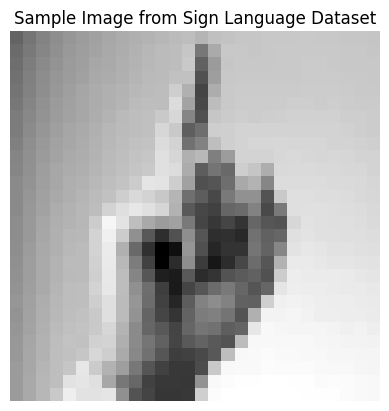

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Select the first image from the dataset for visualization
img_data = X[0].reshape(28, 28) * 255 # Reshape to 2D and scale back to 0-255 for display

plt.imshow(img_data, cmap='gray')
plt.title("Sample Image from Sign Language Dataset")
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


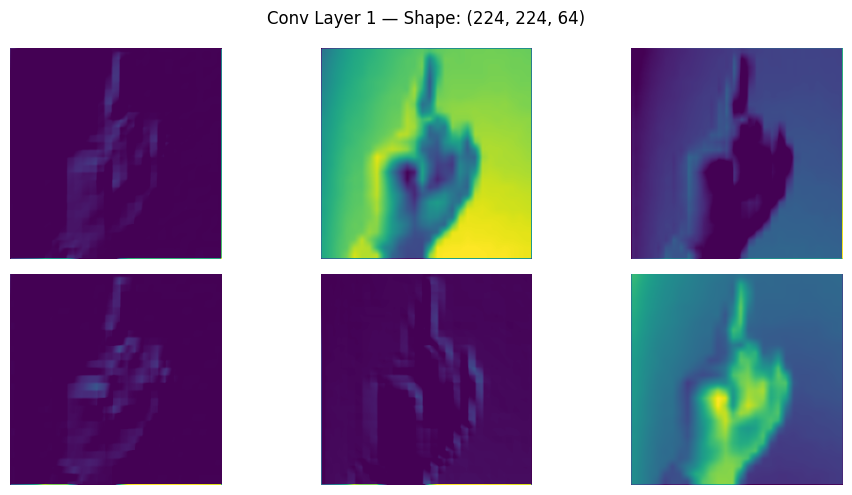

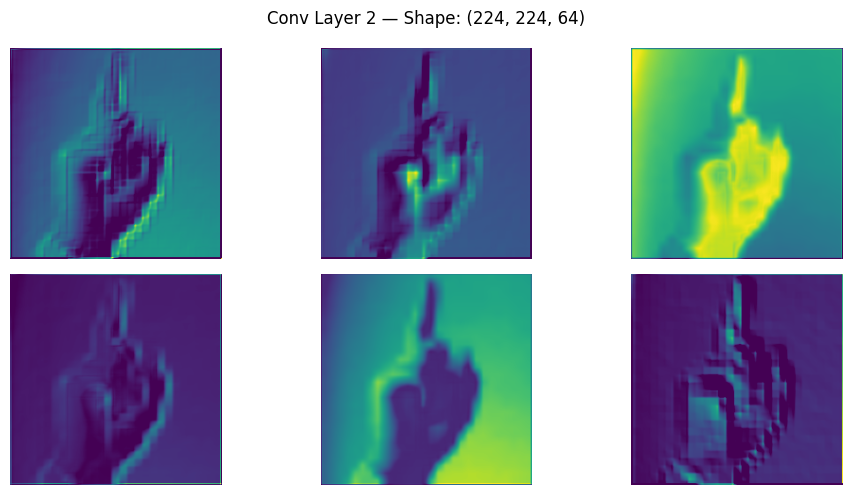

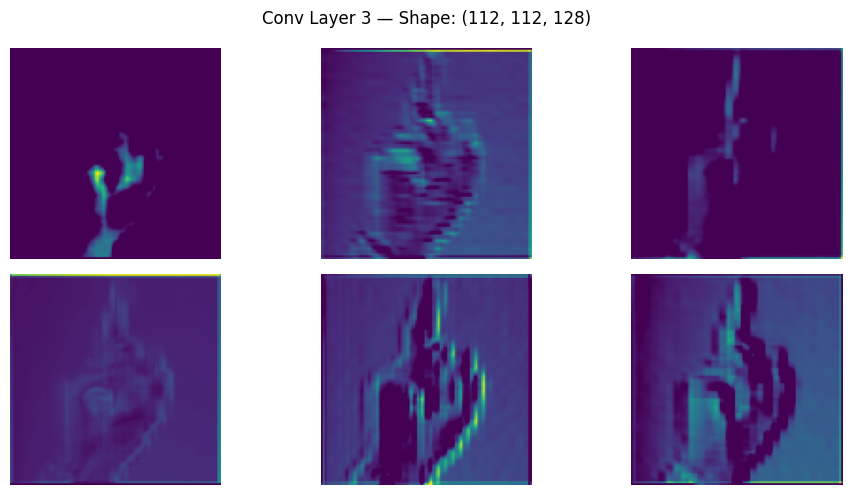

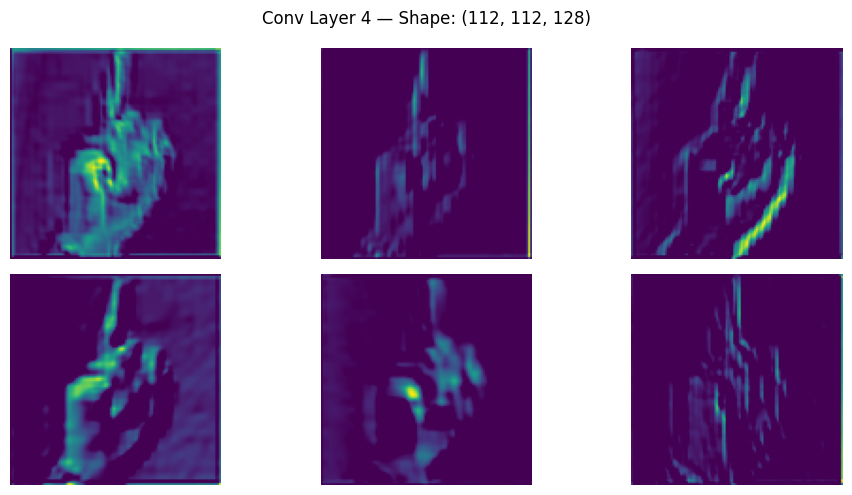

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Use X[0] from the dataset — reshape, scale, convert to RGB, resize to 224x224
img_gray = (X[0].reshape(28, 28) * 255).astype(np.uint8)

# VGG16 needs 3-channel RGB input of size 224x224
img_rgb = np.stack([img_gray] * 3, axis=-1)                          # (28, 28, 3)
img_resized = tf.image.resize(img_rgb, (224, 224)).numpy()           # (224, 224, 3)
img_array = np.expand_dims(img_resized, axis=0)                      # (1, 224, 224, 3)
img_array = tf.keras.applications.vgg16.preprocess_input(img_array)  # VGG normalization

model = tf.keras.applications.VGG16(weights='imagenet', include_top=False)

layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]
feature_map_model = tf.keras.models.Model(inputs=model.input, outputs=layer_outputs)
feature_maps = feature_map_model.predict(img_array)

def plot_feature_maps(feature_maps, max_maps=6):
    for i, fmap in enumerate(feature_maps[:4]):  # first 4 conv layers
        plt.figure(figsize=(10, 5))
        plt.suptitle(f"Conv Layer {i+1} — Shape: {fmap.shape[1:]}")
        for j in range(min(max_maps, fmap.shape[-1])):
            plt.subplot(2, 3, j+1)
            # Normalize each map independently so contrast is visible
            fm = fmap[0, :, :, j]
            fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
            plt.imshow(fm, cmap='viridis')
            plt.axis('off')
        plt.tight_layout()
        plt.show()

plot_feature_maps(feature_maps)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


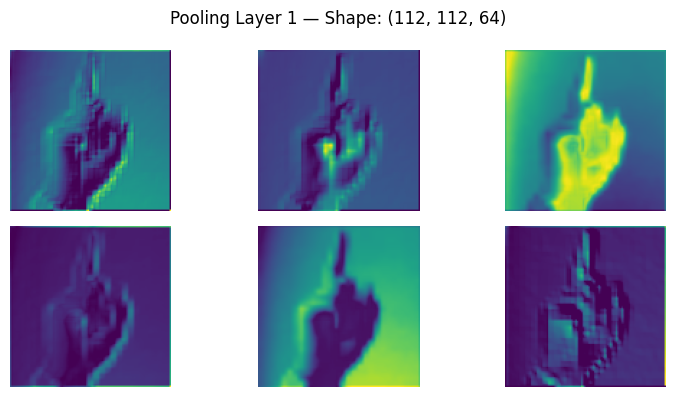

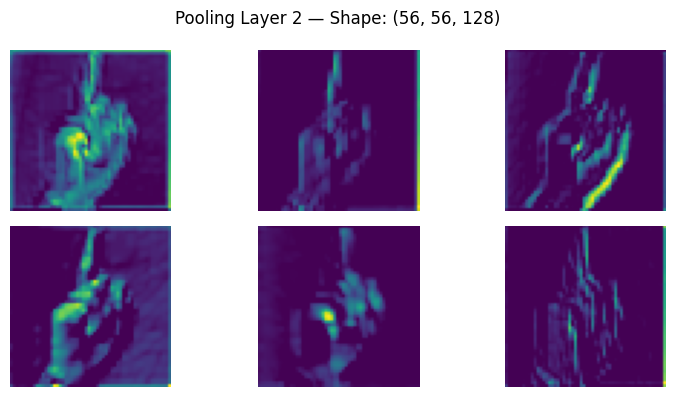

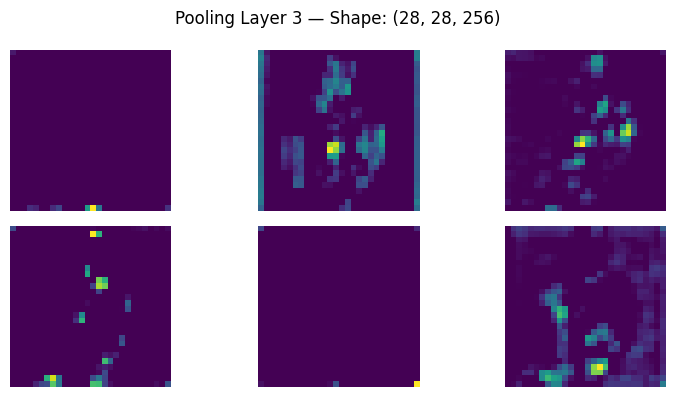

In [ ]:
pool_outputs = [layer.output for layer in model.layers if 'pool' in layer.name]
pool_model = tf.keras.models.Model(inputs=model.input, outputs=pool_outputs)
pooled_maps = pool_model.predict(img_array)  # reuses img_array from block 2

for i, fmap in enumerate(pooled_maps[:3]):
    plt.figure(figsize=(8, 4))
    plt.suptitle(f"Pooling Layer {i+1} — Shape: {fmap.shape[1:]}")
    for j in range(6):
        plt.subplot(2, 3, j+1)
        fm = fmap[0, :, :, j]
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
        plt.imshow(fm, cmap='viridis')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Observations: Pooling layers reduce the dimenstions of the feature maps, they convey most of the information while reducing computational load

Guided Back Propagation

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.5368 - loss: 1.6539
Epoch 2/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8895 - loss: 0.3974
Epoch 3/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9677 - loss: 0.1479
Epoch 4/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9943 - loss: 0.0556
Epoch 5/5
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9985 - loss: 0.0264


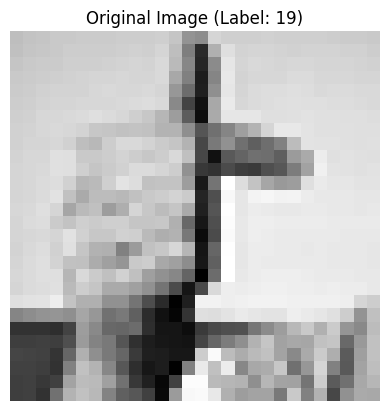

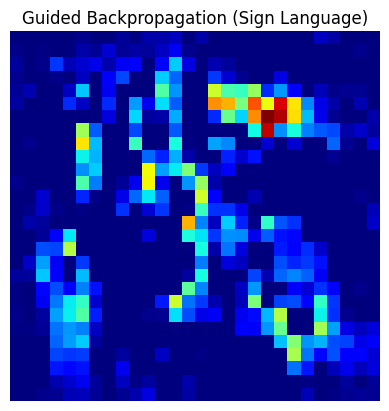

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Load the sign language dataset (assuming df is already loaded and X, y are processed)
# X is (num_samples, 28, 28, 1) and normalized
# y is (num_samples,) with integer labels

# X_train, X_test, y_train, y_test from cell kJV3xaMmKBxY were flattened previously.
# We need the original 28x28x1 shape for the CNN.

# Re-load and reshape data for this specific task to ensure correct dimensions if previous cells changed them
df = pd.read_csv('/content/drive/MyDrive/Sem VI/DL/DL Lab/sign_language/sign_mnist_train.csv')
X_all = df.iloc[:, 1:].values / 255.0 # pixel values, normalize
y_all = df.iloc[:, 0].values        # class labels

X_all = X_all.reshape(-1, 28, 28, 1) # Reshape for CNN input

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

# 2. Build a simple CNN
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(26, activation='softmax') # 26 classes for sign language
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', # Use sparse for integer labels
              metrics=['accuracy'])

# Train briefly (just for demonstration)
model.fit(X_train, y_train, epochs=5, batch_size=128)

# 3. Pick one test image
img = X_test[0:1]  # shape (1,28,28,1)

# Show original image
plt.imshow(img[0,:,:,0], cmap='gray')
plt.title(f"Original Image (Label: {y_test[0]})")
plt.axis('off')
plt.show()

# 4. Guided Backpropagation
input_img = tf.Variable(img)

with tf.GradientTape() as tape:
    tape.watch(input_img)
    preds = model(input_img)

    # Target = predicted class
    class_idx = tf.argmax(preds[0])
    loss = preds[0, class_idx]

# Compute gradients
grads = tape.gradient(loss, input_img)

# Guided backprop (remove negative gradients)
guided_grads = tf.maximum(grads, 0)

# Convert to numpy
guided_grads = guided_grads[0].numpy()

# Normalize
guided_grads = (guided_grads - guided_grads.min()) / (guided_grads.max() - guided_grads.min() + 1e-8)

# 5. Display Gradient
plt.imshow(guided_grads[:,:,0], cmap='jet')
plt.title("Guided Backpropagation (Sign Language)")
plt.axis('off')
plt.show()

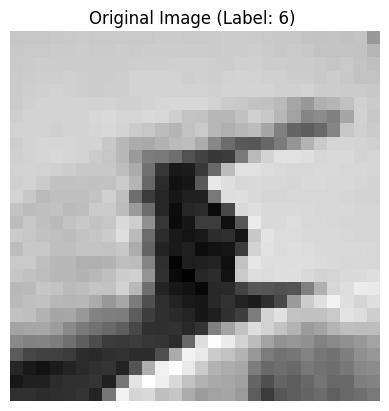

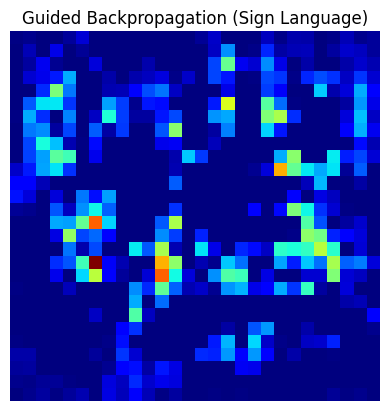

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Use the same model and data splits as in the previous cell for consistency

img = X_test[6:7]  # Pick a different test image from the sign language dataset

# Show original image
plt.imshow(img[0,:,:,0], cmap='gray')
plt.title(f"Original Image (Label: {y_test[6]}) ") # Update label index
plt.axis('off')
plt.show()

# 4. Guided Backpropagation
input_img = tf.Variable(img)

with tf.GradientTape() as tape:
    tape.watch(input_img)
    preds = model(input_img)

    # Target = predicted class
    class_idx = tf.argmax(preds[0])
    loss = preds[0, class_idx]

# Compute gradients
grads = tape.gradient(loss, input_img)

# Guided backprop (remove negative gradients)
guided_grads = tf.maximum(grads, 0)

# Convert to numpy
guided_grads = guided_grads[0].numpy()

# Normalize
guided_grads = (guided_grads - guided_grads.min()) / (guided_grads.max() - guided_grads.min() + 1e-8)

# 5. Display Gradient
plt.imshow(guided_grads[:,:,0], cmap='jet')
plt.title("Guided Backpropagation (Sign Language)")
plt.axis('off')
plt.show()

# Autoencoder


In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

df = pd.read_csv('/content/drive/MyDrive/Sem VI/DL/DL Lab/sign_language/sign_mnist_train.csv')

# First column is the label
x = df.iloc[:, 1:].values    # pixel values
y = df.iloc[:, 0].values    # class labels

# Normalize
x = x / 255.0

# Flatten
x = x.reshape(x.shape[0], 28*28)

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

input_dim = 784  # 28x28 images
encoding_dim = 64  # Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

decoder = Dense(input_dim, activation='sigmoid')(encoded) # output is again the same dimension

autoencoder = Model(input_layer, decoder)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train, x_train, epochs=100, verbose=1, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
decoded_imgs = autoencoder.predict(x_test)



Epoch 1/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.6506 - val_loss: 0.6354
Epoch 2/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.6283 - val_loss: 0.6231
Epoch 3/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6207 - val_loss: 0.6181
Epoch 4/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6163 - val_loss: 0.6152
Epoch 5/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6135 - val_loss: 0.6124
Epoch 6/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6112 - val_loss: 0.6102
Epoch 7/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6091 - val_loss: 0.6090
Epoch 8/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6071 - val_loss: 0.6059
Epoch 9/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6054 - val_loss: 0.6043
Epoch 10/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6036 - val_loss: 0.6029
Epoch 11/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6024 - val_loss: 0.6017
Epoch 12/100
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

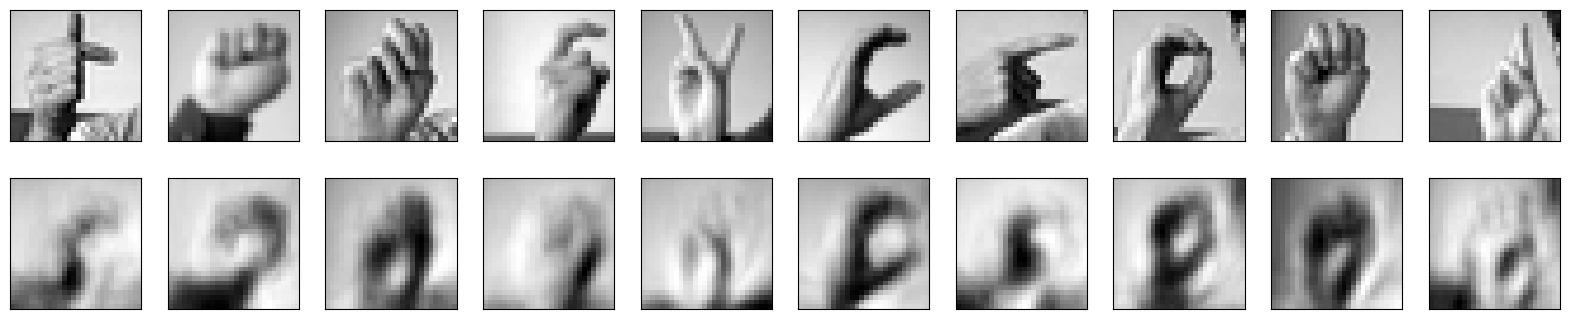

In [ ]:

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

output dim - 256
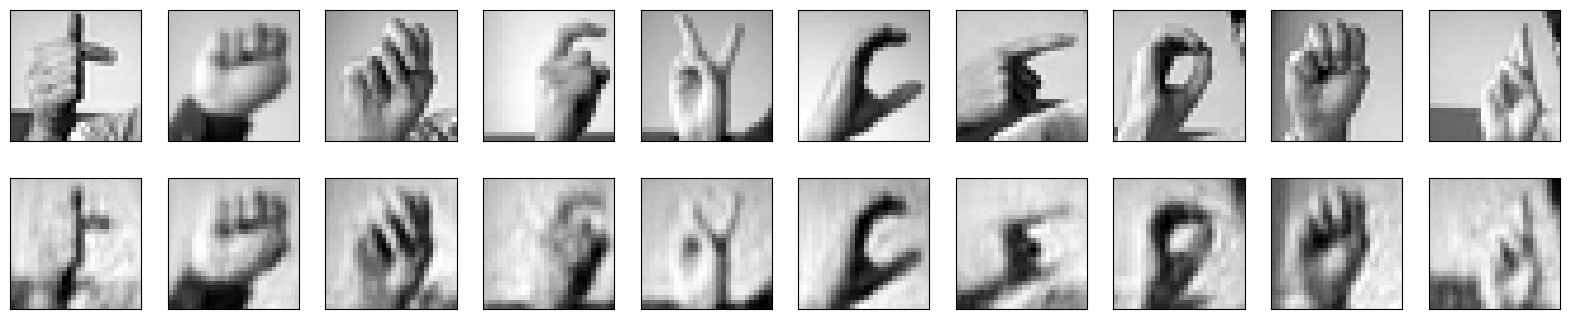

output dim - 128
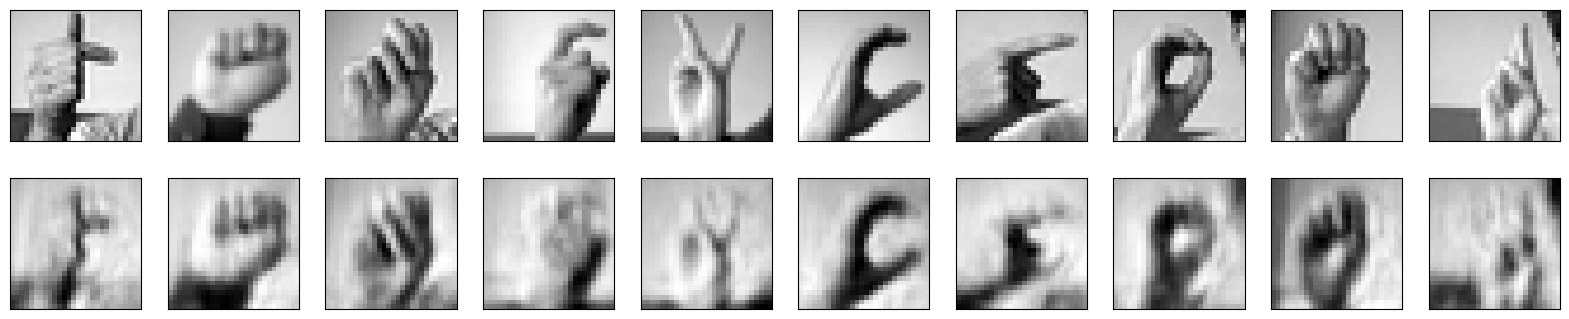

outut dim - 64
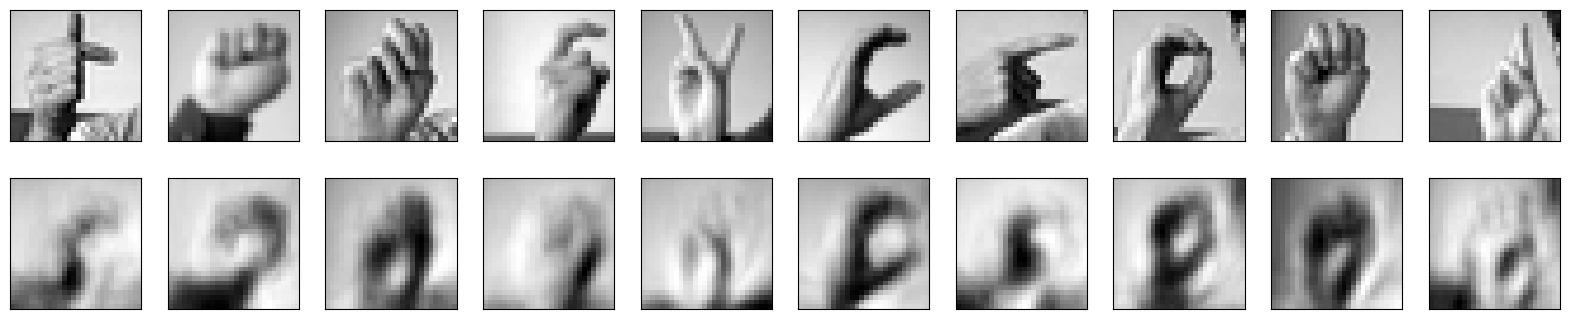